In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv(
    'sales_data.csv',
    parse_dates = ["Date"]
)

## Sales Analytics & Business Performance Analysis
### Business Problem
A business wants to understand its sales performance and identify its strongest products, categories, cities, and sales periods. The goal of this analysis is to clean the sales data, calculate important business KPIs, identify sales patterns, visualize performance, and provide actionable recommendations that can support better business decisions

### Dataset Overview

The dataset contains 1010 sales transactions with information about orders, dates, products, categories, cities, quantities, unit prices, revenue, and customer IDs. After cleaning the data by handling missing values and removing duplicate records, 995 transactions remained for analysis.

### After cleaning:    
- Number of Rows : 995
- Columns: 9
- Main metric: Revenue
- Time-related column: Date
- Product information:
   - Product
   - Category
- Location information: City
- Customer information: Customer_ID



In [3]:
df.head(5)

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID
0,ORD0001,2025-04-17,Desk,Furniture,Rawalpindi,4,239.83,959.32,CUST0021
1,ORD0002,2025-11-27,Desk,Furniture,Lahore,2,204.86,409.72,CUST0088
2,ORD0003,2025-05-11,Mouse,Accessories,Abbottabad,4,23.21,92.84,CUST0258
3,ORD0004,2025-07-11,Backpack,Bags,Karachi,4,59.82,239.28,CUST0277
4,ORD0005,2025-09-10,Laptop,Electronics,Karachi,4,868.98,3475.92,CUST0049


In [4]:
df.tail(5)

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID
1005,ORD0409,2025-01-20,Laptop,Electronics,Lahore,6,799.42,4796.52,CUST0243
1006,ORD0813,2025-04-15,Laptop,Electronics,Rawalpindi,7,843.61,5905.27,CUST0044
1007,ORD0095,2025-10-19,Desk,Furniture,Abbottabad,1,224.04,224.04,CUST0252
1008,ORD0488,2025-09-17,Desk,Furniture,Abbottabad,7,203.79,1426.53,CUST0076
1009,ORD0171,2025-10-20,Keyboard,Accessories,Islamabad,4,47.61,190.44,CUST0092


In [5]:
df.shape

(1010, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order_ID     1010 non-null   object        
 1   Date         1010 non-null   datetime64[ns]
 2   Product      1005 non-null   object        
 3   Category     1010 non-null   object        
 4   City         1003 non-null   object        
 5   Quantity     1010 non-null   int64         
 6   Unit_Price   1010 non-null   float64       
 7   Revenue      1010 non-null   float64       
 8   Customer_ID  1007 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 71.1+ KB


In [7]:
df.describe()

,Date,Quantity,Unit_Price,Revenue
count,1010,1010.000000,1010.000000,1010.000000
mean,2025-07-04 23:37:11.287128832,4.149505,203.649149,832.596158
min,2025-01-01 00:00:00,1.000000,7.250000,7.250000
25%,2025-04-03 06:00:00,2.000000,25.462500,92.860000
50%,2025-07-07 00:00:00,4.000000,66.305000,257.430000
75%,2025-10-07 00:00:00,6.000000,216.427500,907.360000
max,2025-12-31 00:00:00,70.000000,934.950000,13802.600000
std,NaN,3.424454,270.126714,1354.441110


## Data Cleaning

The dataset was checked for missing values, duplicate records, incorrect data types, and unusual values. Missing Product values were removed because product information is essential for product-level analysis. Missing City values were replaced with "Other" to preserve the transactions. Duplicate records were removed. Statistical outliers in Revenue were investigated and found to represent legitimate transactions, so they were retained.

### Cleaning Summary

- Original records: 1,010
- Records after cleaning: 995
- Missing values: None
- Duplicate records: None
- Revenue outliers: Investigated and retained

In [8]:
df.isna().sum() # To find out null values in the dataset

Order_ID       0
Date           0
Product        5
Category       0
City           7
Quantity       0
Unit_Price     0
Revenue        0
Customer_ID    3
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(10)

In [10]:
df['Product'].unique() 


array(['Desk', 'Mouse', 'Backpack', 'Laptop', 'Notebook', 'Headphones',
       'Smartphone', 'Keyboard', 'Water Bottle', 'Office Chair', nan],
      dtype=object)

In [11]:
df['Product'].value_counts()

Product
Keyboard        113
Headphones      109
Laptop          107
Water Bottle    102
Mouse           101
Office Chair    101
Backpack         97
Desk             95
Smartphone       92
Notebook         88
Name: count, dtype: int64

In [12]:
df['Product'].nunique()

10

In [13]:
df[['Product', 'Category', 'City', 'Customer_ID']].nunique()

Product         10
Category         6
City             6
Customer_ID    293
dtype: int64

In [14]:
df['Date'].min(), df['Date'].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [15]:
minimum = df[['Quantity', 'Unit_Price', "Revenue"]].min()
maximum = df[['Quantity', 'Unit_Price', "Revenue"]].max()

print("Min:\n", minimum, '\nMax:\n', maximum)

Min:
 Quantity      1.00
Unit_Price    7.25
Revenue       7.25
dtype: float64 
Max:
 Quantity         70.00
Unit_Price      934.95
Revenue       13802.60
dtype: float64


In [16]:
df.isna().sum()

Order_ID       0
Date           0
Product        5
Category       0
City           7
Quantity       0
Unit_Price     0
Revenue        0
Customer_ID    3
dtype: int64

In [17]:
df[df.isna().any(axis=1)] # to show rows with nan value

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID
5,ORD0006,2025-09-28,Notebook,Stationery,NaN,4,8.76,35.04,CUST0175
201,ORD0202,2025-04-19,NaN,Accessories,Islamabad,2,45.23,90.46,CUST0215
230,ORD0231,2025-09-23,Water Bottle,Lifestyle,NaN,4,21.94,87.76,CUST0065
322,ORD0323,2025-10-31,Headphones,Electronics,Islamabad,5,85.81,429.05,NaN
474,ORD0475,2025-07-20,Headphones,Electronics,NaN,3,84.06,252.18,CUST0173
485,ORD0486,2025-04-03,NaN,Lifestyle,Abbottabad,3,21.57,64.71,CUST0232
506,ORD0507,2025-01-02,NaN,Accessories,Rawalpindi,6,41.59,249.54,CUST0166
510,ORD0511,2025-04-09,Mouse,Accessories,NaN,6,26.76,160.56,CUST0073
563,ORD0564,2025-03-29,Office Chair,Furniture,Islamabad,6,194.25,1165.50,NaN
743,ORD0744,2025-06-02,Smartphone,Electronics,NaN,2,510.23,1020.46,CUST0048


In [18]:
df.dtypes

Order_ID               object
Date           datetime64[ns]
Product                object
Category               object
City                   object
Quantity                int64
Unit_Price            float64
Revenue               float64
Customer_ID            object
dtype: object

In [19]:
# to fill nan values
df['City'] = df['City'].fillna('Other') 


In [20]:
df['Product'].isna().sum()

np.int64(5)

In [21]:
df = df.dropna(subset = ['Product'])  # to drop nan values

In [22]:
df.isna().sum()

Order_ID       0
Date           0
Product        0
Category       0
City           0
Quantity       0
Unit_Price     0
Revenue        0
Customer_ID    3
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(10)

In [24]:
# to show duplicates rows 
df[df.duplicated()]

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID
1000,ORD0779,2025-07-07,Office Chair,Furniture,Islamabad,3,188.50,565.50,CUST0270
1001,ORD0335,2025-06-19,Notebook,Stationery,Peshawar,2,7.78,15.56,CUST0154
1002,ORD0272,2025-08-02,Office Chair,Furniture,Abbottabad,1,167.79,167.79,CUST0117
1003,ORD0803,2025-01-28,Office Chair,Furniture,Islamabad,3,168.92,506.76,CUST0038
1004,ORD0217,2025-02-13,Smartphone,Electronics,Lahore,4,534.71,2138.84,CUST0017
1005,ORD0409,2025-01-20,Laptop,Electronics,Lahore,6,799.42,4796.52,CUST0243
1006,ORD0813,2025-04-15,Laptop,Electronics,Rawalpindi,7,843.61,5905.27,CUST0044
1007,ORD0095,2025-10-19,Desk,Furniture,Abbottabad,1,224.04,224.04,CUST0252
1008,ORD0488,2025-09-17,Desk,Furniture,Abbottabad,7,203.79,1426.53,CUST0076
1009,ORD0171,2025-10-20,Keyboard,Accessories,Islamabad,4,47.61,190.44,CUST0092


In [25]:
df = df.drop_duplicates()

In [26]:
df.shape

(995, 9)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
Min = df[['Quantity', "Unit_Price", "Revenue"]].min()
Max = df[['Quantity', "Unit_Price", "Revenue"]].max()
print("min\n", Min, '\nmax\n', Max)

min
 Quantity      1.00
Unit_Price    7.25
Revenue       7.25
dtype: float64 
max
 Quantity         70.00
Unit_Price      934.95
Revenue       13802.60
dtype: float64


In [29]:
df.describe()

,Date,Quantity,Unit_Price,Revenue
count,995,995.000000,995.000000,995.000000
mean,2025-07-05 20:04:06.030150656,4.156784,203.167065,827.845829
min,2025-01-01 00:00:00,1.000000,7.250000,7.250000
25%,2025-04-07 00:00:00,2.000000,25.420000,92.880000
50%,2025-07-07 00:00:00,4.000000,60.240000,257.700000
75%,2025-10-07 12:00:00,6.000000,216.375000,906.240000
max,2025-12-31 00:00:00,70.000000,934.950000,13802.600000
std,NaN,3.441307,270.208561,1346.948770


## To Find out outliers and determine whether they are actual transactions or not.

In [30]:
q1 = df['Revenue'].quantile(0.25)
q3 = df['Revenue'].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5 *IQR
upper_limit = q3 + 1.5 * IQR

In [31]:
iqr_outlier = df[(df['Revenue'] < lower_limit) | (df['Revenue'] > upper_limit)]

In [32]:
iqr_outlier.shape

(124, 9)

In [33]:
iqr_outlier

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID
4,ORD0005,2025-09-10,Laptop,Electronics,Karachi,4,868.98,3475.92,CUST0049
20,ORD0021,2025-05-11,Laptop,Electronics,Peshawar,3,785.33,2355.99,CUST0005
29,ORD0030,2025-06-01,Laptop,Electronics,Lahore,3,810.80,2432.40,CUST0160
35,ORD0036,2025-11-21,Laptop,Electronics,Karachi,7,901.53,6310.71,CUST0098
43,ORD0044,2025-12-06,Laptop,Electronics,Abbottabad,4,917.75,3671.00,CUST0227
...,...,...,...,...,...,...,...,...,...
929,ORD0930,2025-01-04,Laptop,Electronics,Peshawar,4,831.60,3326.40,CUST0132
943,ORD0944,2025-01-11,Laptop,Electronics,Karachi,4,773.22,3092.88,CUST0210
968,ORD0969,2025-03-21,Smartphone,Electronics,Abbottabad,7,540.74,3785.18,CUST0126
973,ORD0974,2025-11-09,Smartphone,Electronics,Lahore,7,521.82,3652.74,CUST0088


In [34]:
df.shape

(995, 9)

In [35]:
df.isna().sum()

Order_ID       0
Date           0
Product        0
Category       0
City           0
Quantity       0
Unit_Price     0
Revenue        0
Customer_ID    3
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.dtypes

Order_ID               object
Date           datetime64[ns]
Product                object
Category               object
City                   object
Quantity                int64
Unit_Price            float64
Revenue               float64
Customer_ID            object
dtype: object

### Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand sales performance and identify important patterns in the dataset. The analysis focuses on revenue, products, categories, cities, customers, sales quantity, and monthly trends.

In [38]:
# EDA -- EXPOLATORY DATA ANALYSIS
# total revenue
df['Revenue'].sum()

np.float64(823706.6)

In [39]:
# to show which product generates the most revenue
df.groupby('Product')["Revenue"].sum().sort_values(ascending=False)

Product
Laptop          354726.49
Smartphone      197999.26
Office Chair     92495.75
Desk             76642.94
Headphones       39132.43
Backpack         21048.24
Keyboard         20141.65
Mouse            10217.77
Water Bottle      8625.65
Notebook          2676.42
Name: Revenue, dtype: float64

In [40]:
# revenue by category
df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

Category
Electronics    591858.18
Furniture      169138.69
Accessories     30359.42
Bags            21048.24
Lifestyle        8625.65
Stationery       2676.42
Name: Revenue, dtype: float64

In [41]:
# Revenue by city 
df.groupby('City')['Revenue'].sum().sort_values()

City
Other           2593.08
Karachi       124331.90
Islamabad     124915.59
Peshawar      132150.36
Rawalpindi    138789.51
Lahore        148744.45
Abbottabad    152181.71
Name: Revenue, dtype: float64

In [42]:
# number of units 
df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

Product
Office Chair    514
Headphones      488
Keyboard        448
Water Bottle    433
Laptop          414
Mouse           413
Backpack        376
Smartphone      361
Desk            350
Notebook        339
Name: Quantity, dtype: int64

In [43]:
# Average revenue per transaction
df.groupby('Product')["Revenue"].mean().sort_values(ascending=False)

Product
Laptop          3378.347524
Smartphone      2175.816044
Office Chair     943.834184
Desk             824.117634
Headphones       359.013119
Backpack         216.992165
Keyboard         179.836161
Mouse            101.166040
Water Bottle      84.565196
Notebook          30.763448
Name: Revenue, dtype: float64

In [44]:
# For monthly revenue
df.groupby(df['Date'].dt.to_period("M"))['Revenue'].sum().sort_values(ascending=False)

Date
2025-05    88171.97
2025-01    85886.39
2025-06    80463.25
2025-09    77470.19
2025-10    70820.29
2025-08    69203.50
2025-11    64459.47
2025-04    64295.52
2025-12    63643.63
2025-07    62436.48
2025-02    56725.25
2025-03    40130.66
Freq: M, Name: Revenue, dtype: float64

In [45]:
# 2 for monthly revenue
df.set_index('Date')['Revenue'].resample('ME').sum().sort_values(ascending=False)

Date
2025-05-31    88171.97
2025-01-31    85886.39
2025-06-30    80463.25
2025-09-30    77470.19
2025-10-31    70820.29
2025-08-31    69203.50
2025-11-30    64459.47
2025-04-30    64295.52
2025-12-31    63643.63
2025-07-31    62436.48
2025-02-28    56725.25
2025-03-31    40130.66
Name: Revenue, dtype: float64

In [46]:
monthly_revenue = df.set_index('Date')['Revenue'].resample('ME').sum()
print(monthly_revenue)

Date
2025-01-31    85886.39
2025-02-28    56725.25
2025-03-31    40130.66
2025-04-30    64295.52
2025-05-31    88171.97
2025-06-30    80463.25
2025-07-31    62436.48
2025-08-31    69203.50
2025-09-30    77470.19
2025-10-31    70820.29
2025-11-30    64459.47
2025-12-31    63643.63
Freq: ME, Name: Revenue, dtype: float64


In [47]:
# to show highest revenue generator customers
df.groupby("Customer_ID")['Revenue'].sum().sort_values(ascending=False).head(5)

Customer_ID
CUST0008    18022.79
CUST0176    16459.06
CUST0059    16141.57
CUST0216    12729.07
CUST0109    11572.90
Name: Revenue, dtype: float64

In [48]:
# Revenue by  category  vs quantity
df.groupby('Category')[['Quantity', 'Revenue']].sum().sort_values(by =['Revenue'], ascending=False)

,Quantity,Revenue
Category,,
Electronics,1263,591858.18
Furniture,864,169138.69
Accessories,861,30359.42
Bags,376,21048.24
Lifestyle,433,8625.65
Stationery,339,2676.42


In [49]:
# Average unit price by category
df.groupby('Category')['Unit_Price'].mean().sort_values(ascending=False)

Category
Electronics    486.913738
Furniture      199.001309
Bags            55.585876
Accessories     35.358404
Lifestyle       19.829118
Stationery       7.902874
Name: Unit_Price, dtype: float64

In [50]:
# to show relationship between columns( -1 .. 0 ... +1)
df['Quantity'].corr(df['Revenue'])

np.float64(0.43975325500602735)

In [51]:
# to calculate averager revenue per product
df['Average_Revenue'] = df["Revenue"] / df["Quantity"]

In [52]:
df['Average_Revenue'].head(5)

0    239.83
1    204.86
2     23.21
3     59.82
4    868.98
Name: Average_Revenue, dtype: float64

In [53]:
# to show average revenue by category
df.groupby('Category')['Average_Revenue'].mean().sort_values(ascending=False)

Category
Electronics    486.913738
Furniture      199.001309
Bags            55.585876
Accessories     35.358404
Lifestyle       19.829118
Stationery       7.902874
Name: Average_Revenue, dtype: float64

In [54]:
df.groupby('Category')['Revenue'].mean().sort_values(ascending=False)

Category
Electronics    1940.518623
Furniture       885.542880
Bags            216.992165
Accessories     142.532488
Lifestyle        84.565196
Stationery       30.763448
Name: Revenue, dtype: float64

In [55]:
# to get product revenue for every row 
df['Product_Revenue'] = df.groupby("Product")['Revenue'].transform('sum')


In [56]:
# to get percentage contribution of each product in revenue 
df['Revenue_percentage'] = (df['Product_Revenue']/df['Revenue'].sum())*100
df.head(5)

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID,Average_Revenue,Product_Revenue,Revenue_percentage
0,ORD0001,2025-04-17,Desk,Furniture,Rawalpindi,4,239.83,959.32,CUST0021,239.83,76642.94,9.304641
1,ORD0002,2025-11-27,Desk,Furniture,Lahore,2,204.86,409.72,CUST0088,204.86,76642.94,9.304641
2,ORD0003,2025-05-11,Mouse,Accessories,Abbottabad,4,23.21,92.84,CUST0258,23.21,10217.77,1.240462
3,ORD0004,2025-07-11,Backpack,Bags,Karachi,4,59.82,239.28,CUST0277,59.82,21048.24,2.555308
4,ORD0005,2025-09-10,Laptop,Electronics,Karachi,4,868.98,3475.92,CUST0049,868.98,354726.49,43.064665


In [57]:
# to show product, revenue and percentage_revenue for a report 
df.groupby('Product').agg({
    'Revenue' : 'sum',
    'Revenue_percentage' : 'first'
}).sort_values('Revenue', ascending=False)

,Revenue,Revenue_percentage
Product,,
Laptop,354726.49,43.064665
Smartphone,197999.26,24.037595
Office Chair,92495.75,11.229211
Desk,76642.94,9.304641
Headphones,39132.43,4.750773
Backpack,21048.24,2.555308
Keyboard,20141.65,2.445246
Mouse,10217.77,1.240462
Water Bottle,8625.65,1.047175


In [58]:
# to get category revenue for every row
df['Category_revenue'] = df.groupby("Category")['Revenue'].transform('sum')

In [59]:
# percentage revenue for each category
df['Category_percentage'] = (df['Category_revenue']/df['Revenue'].sum())*100

In [60]:
# to show categories revenue and percentage revenue 
df.groupby('Category').agg({
    "Revenue" : 'sum',
    "Category_percentage" : "first"
}).sort_values('Revenue', ascending=False)

,Revenue,Category_percentage
Category,,
Electronics,591858.18,71.853034
Furniture,169138.69,20.533851
Accessories,30359.42,3.685708
Bags,21048.24,2.555308
Lifestyle,8625.65,1.047175
Stationery,2676.42,0.324924


In [61]:
df["Month"] = df['Date'].dt.month

In [62]:
monthly_revenue = df.groupby(["Month", "Product"])["Revenue"].sum().sort_values(ascending=False)
print(monthly_revenue.head(10))

Month  Product   
1      Laptop        48435.46
5      Laptop        38097.79
6      Laptop        36070.79
4      Laptop        35641.03
9      Laptop        32851.46
10     Laptop        32003.50
7      Laptop        30883.95
5      Smartphone    30374.72
8      Laptop        27730.85
12     Smartphone    24856.10
Name: Revenue, dtype: float64


In [63]:
top_product_index = monthly_revenue.groupby(level="Month").idxmax()


In [64]:
top_product_monthly = monthly_revenue.loc[top_product_index]
print(top_product_monthly)

Month  Product   
1      Laptop        48435.46
2      Laptop        20470.16
3      Smartphone    12683.16
4      Laptop        35641.03
5      Laptop        38097.79
6      Laptop        36070.79
7      Laptop        30883.95
8      Laptop        27730.85
9      Laptop        32851.46
10     Laptop        32003.50
11     Laptop        24335.56
12     Smartphone    24856.10
Name: Revenue, dtype: float64


In [65]:
df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

Product
Office Chair    514
Headphones      488
Keyboard        448
Water Bottle    433
Laptop          414
Mouse           413
Backpack        376
Smartphone      361
Desk            350
Notebook        339
Name: Quantity, dtype: int64

In [66]:
(df['Revenue'].sum()/ len(df)).round(2)

np.float64(827.85)

In [67]:
df.groupby('Category')['Revenue'].mean().sort_values(ascending=False)

Category
Electronics    1940.518623
Furniture       885.542880
Bags            216.992165
Accessories     142.532488
Lifestyle        84.565196
Stationery       30.763448
Name: Revenue, dtype: float64

In [68]:
df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

City
Abbottabad    152181.71
Lahore        148744.45
Rawalpindi    138789.51
Peshawar      132150.36
Islamabad     124915.59
Karachi       124331.90
Other           2593.08
Name: Revenue, dtype: float64

In [69]:
df = df.drop(['Average_Revenue',
       'Product_Revenue', 'Revenue_percentage', 'Category_revenue',
       'Category_percentage', 'Month'], axis=1)

In [70]:
df.head()

,Order_ID,Date,Product,Category,City,Quantity,Unit_Price,Revenue,Customer_ID
0,ORD0001,2025-04-17,Desk,Furniture,Rawalpindi,4,239.83,959.32,CUST0021
1,ORD0002,2025-11-27,Desk,Furniture,Lahore,2,204.86,409.72,CUST0088
2,ORD0003,2025-05-11,Mouse,Accessories,Abbottabad,4,23.21,92.84,CUST0258
3,ORD0004,2025-07-11,Backpack,Bags,Karachi,4,59.82,239.28,CUST0277
4,ORD0005,2025-09-10,Laptop,Electronics,Karachi,4,868.98,3475.92,CUST0049


### Key Performance Indicators (KPIs)

The following KPIs provide a high-level overview of the business's sales performance. They summarize total revenue, total units sold, total orders, and average order value.

In [71]:
# totol Revenue 
total_revenue = df['Revenue'].sum()
print(total_revenue)

823706.6


In [72]:
# Total Quantity 
total_quantity = df['Quantity'].sum()
print(total_quantity)

4136


In [73]:
# AVERAGE ORDER VALUES 
average_order_value = (total_revenue/len(df)).round(2)
print(average_order_value)

827.85


In [74]:
# TOTAL ORDERS
total_order = len(df['Product'])
print(total_order)

995


In [75]:
report = pd.DataFrame({
    "KPI" :[
        "Total Revenue", 
        "Total units sold", 
        "Totol orders", 
        'Average order value'
        
    ],
    "Value":[
        total_revenue,
        total_quantity,
        total_order, 
        average_order_value
       
    ]
})
print(report)

                   KPI      Value
0        Total Revenue  823706.60
1     Total units sold    4136.00
2         Totol orders     995.00
3  Average order value     827.85


### Top Performers

This section identifies the best-performing product, category, city, and month based on total revenue. These results help the business understand which areas are contributing the most to overall sales performance.

In [76]:
top_month =  df.groupby(df['Date'].dt.month_name())['Revenue'].sum().sort_values(ascending=False).head(1)
print(top_month)

Date
May    88171.97
Name: Revenue, dtype: float64


In [77]:
top_product = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(1)
print(top_product)

Product
Laptop    354726.49
Name: Revenue, dtype: float64


In [78]:
top_category = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(1)
print(top_category)

Category
Electronics    591858.18
Name: Revenue, dtype: float64


In [79]:
top_city = df.groupby("City")["Revenue"].sum().sort_values(ascending=False).head(1)
print(top_city)

City
Abbottabad    152181.71
Name: Revenue, dtype: float64


In [80]:
Report = pd.DataFrame({
    "KPI" :[
        "Top Category", 
        "Top Product", 
        "Top City", 
        'Top Month'
        
    ],
    "Name":[
        top_category.index[0],
        top_product.index[0],
        top_city.index[0], 
        top_month.index[0]
    ], 
    "Performance" : [
        top_category.values[0],
        top_product.values[0],
        top_city.values[0], 
        top_month.values[0]
        
    ]
})
print(Report)

            KPI         Name  Performance
0  Top Category  Electronics    591858.18
1   Top Product       Laptop    354726.49
2      Top City   Abbottabad    152181.71
3     Top Month          May     88171.97


### Visualizations

The following visualizations present the key findings from the sales analysis. They help identify high-performing products and categories, monthly revenue trends, and the relationship between quantity sold and revenue.

=== Revenue by Product ===


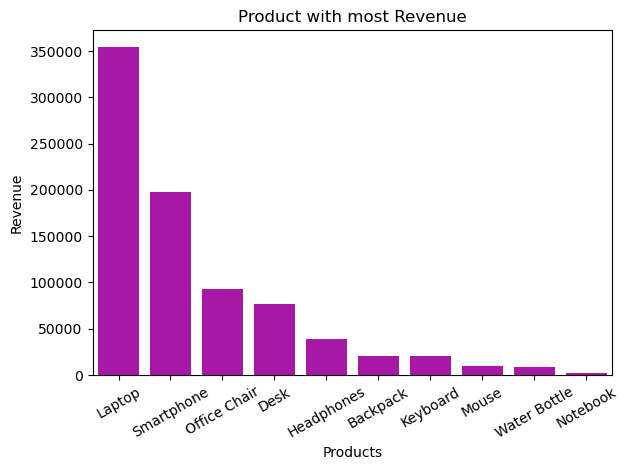

In [81]:
print("=== Revenue by Product ===")

sns.barplot(df.groupby("Product")['Revenue'].sum().sort_values(ascending=False), color="m")
plt.title("Product with most Revenue")
plt.xlabel("Products")
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


=== Revenue by Category ===


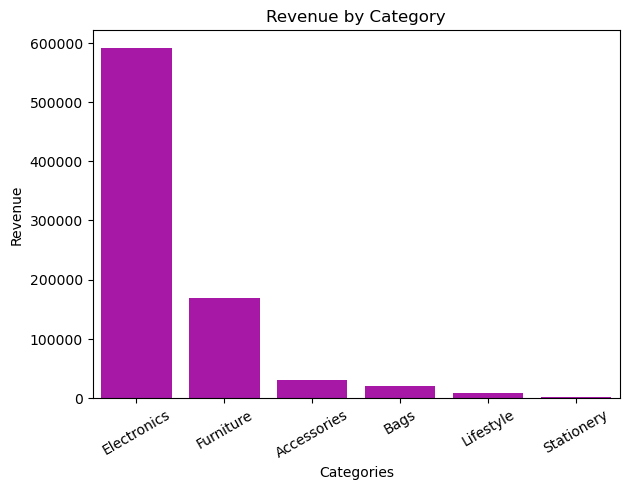

In [82]:
print("=== Revenue by Category ===")

sns.barplot(df.groupby('Category')['Revenue'].sum().sort_values(ascending=False), color='m')

plt.xlabel("Categories")
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.title('Revenue by Category')
plt.show()


=== Monthly Revenue Trend ===


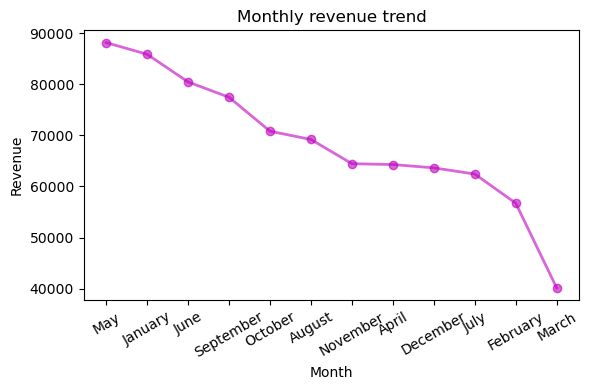

In [83]:
print("=== Monthly Revenue Trend ===")

monthly_revenue = df.groupby(df['Date'].dt.month_name())['Revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, alpha=0.6, color='m')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly revenue trend')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

=== Quantity Vs Revenue ===


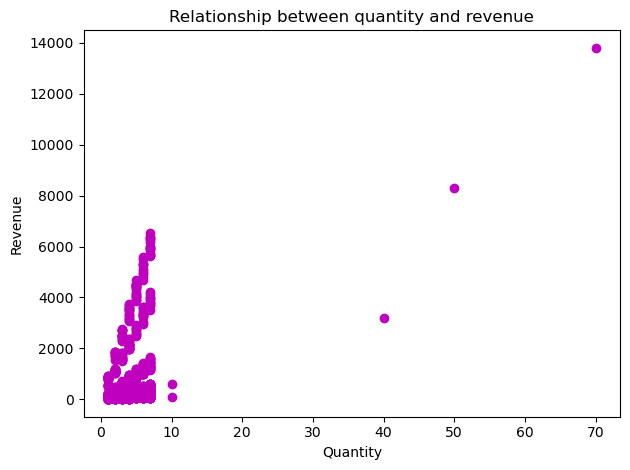

In [84]:
print("=== Quantity Vs Revenue ===")

plt.scatter(df['Quantity'], df['Revenue'], color="m")
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.title('Relationship between quantity and revenue')
plt.tight_layout()
plt.show()

## Business Insights and Recommendations

### 1. Electronics is the main revenue driver:
Electronics generated approximately 591,858 in revenue, making it the strongest category. The business should continue focusing on this category while also considering profit margins.

### 2. Laptop is the top-performing product:
Laptops generated approximately 354,726 in revenue and contributed around 43% of total revenue. The business should maintain sufficient stock and continue monitoring demand for this product.

### 3. Sales vary across months:
May was the highest-revenue month, generating approximately 88,171. The business should investigate the reasons behind strong and weak months to improve seasonal planning.

### 4. Quantity alone does not determine revenue:
The correlation between quantity and revenue was approximately 0.43, indicating a moderate positive relationship. The business should consider both sales volume and product pricing when making decisions.


## Conclusion

This sales analysis provided an overview of the business's sales performance using 995 cleaned transactions. The analysis identified the top-performing products, categories, cities, and sales periods while also examining monthly trends and the relationship between quantity sold and revenue.

Electronics was the strongest revenue-generating category, while Laptop was the top-performing product. May recorded the highest monthly revenue. The analysis also showed that quantity and revenue have a moderate positive relationship, indicating that product pricing also plays an important role in revenue generation.

Overall, these findings can help the business make better decisions about inventory, product focus, marketing, and sales planning.